In [1]:
import pandas as pd
import numpy as np 

TrainData = pd.read_csv("../../Dados/DataSpline.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [2]:
TestData = pd.read_csv("../../Dados/DataSpline2.csv")
TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)
TestData = TestData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [3]:
ValData = pd.read_csv("../../Dados/DataSpline3.csv")
ValData.index = (np.arange(0, len(ValData), 1).astype(float) * 0.07).round(5)
ValData = ValData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [4]:
import matplotlib.pyplot as plt

PREDICTORS = ["Wd", "We"]
TARGET = ["theta(Wd,We)"]

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Paletas manuais para preditores e alvos
    predictor_colors = plt.cm.tab10.colors
    target_colors = plt.cm.Set2.colors

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot preditores no eixo esquerdo
    for i, preds in enumerate(PREDICTORS):
        ax1.plot(df.index, df[preds], marker="o", label=preds,
                 color=predictor_colors[i % len(predictor_colors)],
                 linewidth=2)

    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")
    ax1.tick_params(axis='y', labelcolor="black")

    # Plot alvos no eixo direito, se ativado
    if PlotOut:
        ax2 = ax1.twinx()
        for i, target in enumerate(TARGET):
            ax2.plot(df.index, df[target], marker="s", linestyle="--", label=target,
                     color=target_colors[i % len(target_colors)],
                     linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")
        ax2.tick_params(axis='y', labelcolor="gray")

    # Legendas separadas
    leg1 = ax1.legend(loc="upper left", title="Preditores")
    ax1.add_artist(leg1)  # Necessário para manter ambas visíveis
    if PlotOut:
        ax2.legend(loc="upper right", title="Alvos")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)
    
    # Layout e exportação
    plt.tight_layout()
    plt.show()


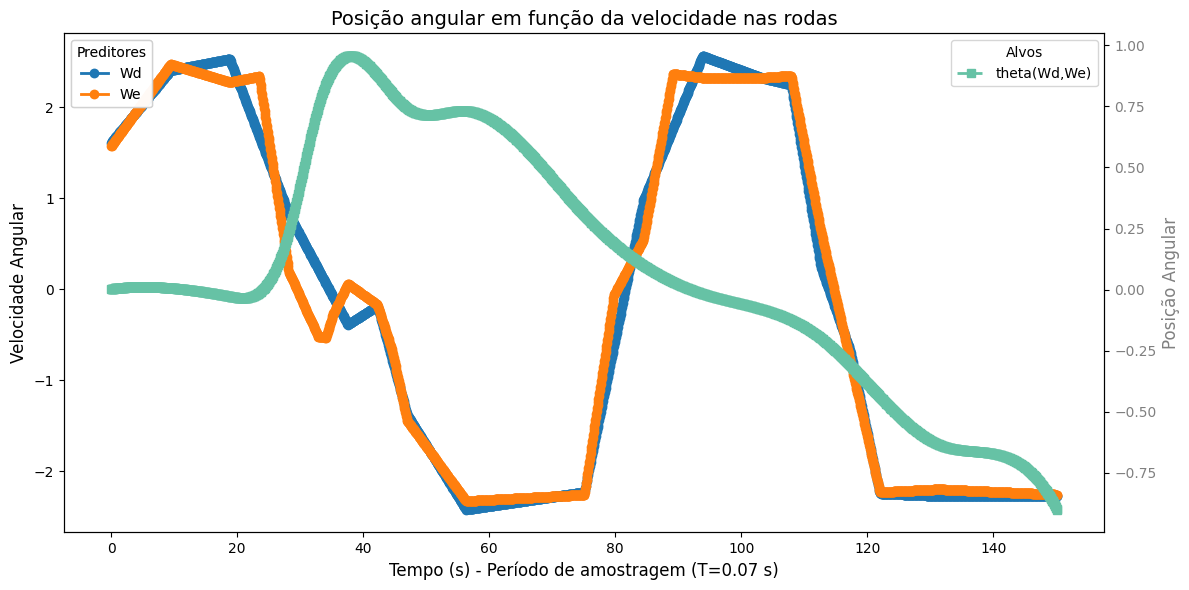

In [5]:
PlotTimeSeries(TrainData)

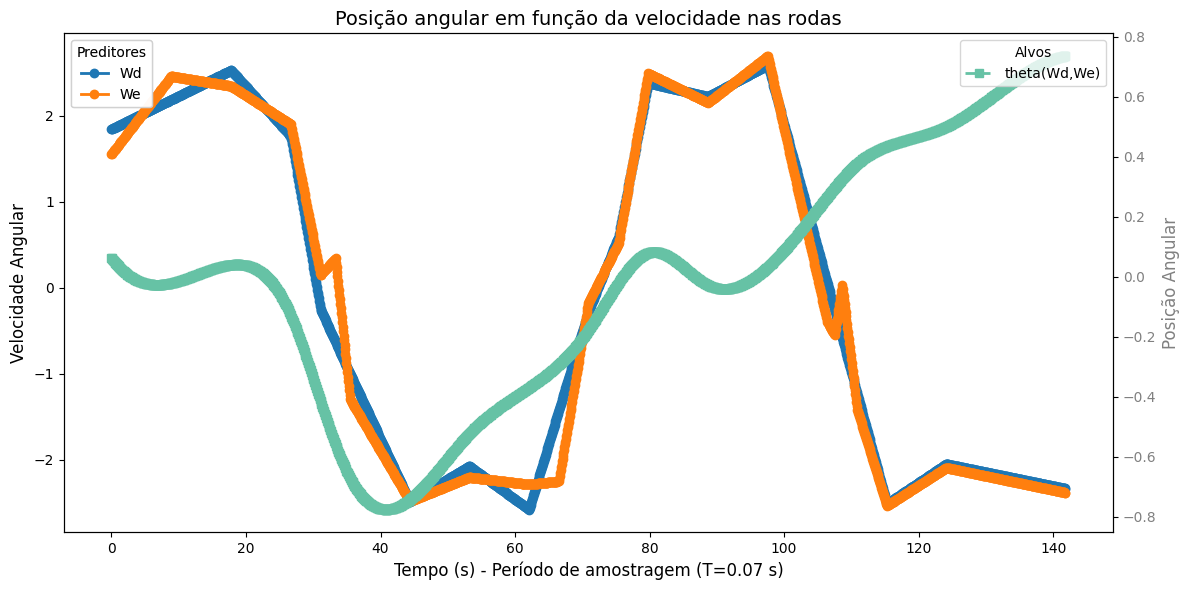

In [6]:
PlotTimeSeries(TestData)

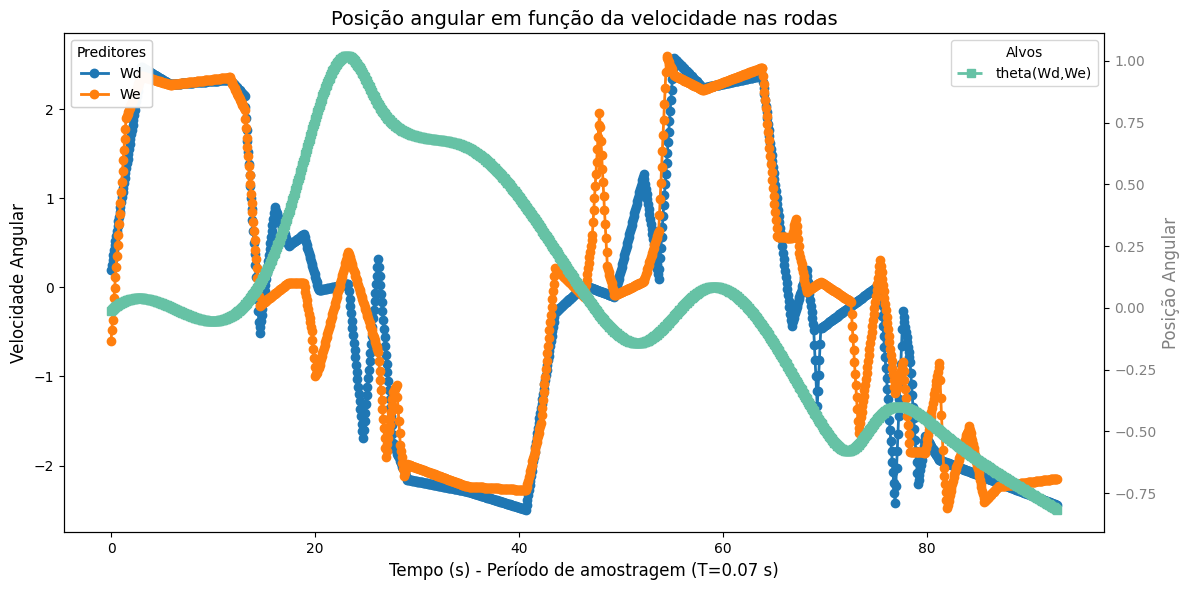

In [7]:
PlotTimeSeries(ValData)

In [8]:
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

def get_XY(data, time_steps, units, output_dim):
    total_samples = (len(data) - time_steps) // time_steps

    X = []
    Y = []
    
    for i in range(total_samples):
        start_idx = i * time_steps
        end_idx = start_idx + time_steps

        X_seq = data.iloc[start_idx:end_idx][PREDICTORS].values  # shape: (time_steps, features)
        Y_target = data.iloc[end_idx][TARGET]  # escalar

        X.append(X_seq)
        Y.append(Y_target)

    X = np.array(X)  # shape: (batch, time_steps, features)
    Y =  Y = np.array(Y).reshape(-1, 1).repeat(output_dim, axis=1)  # shape (batch, output_dim)
    h0 = np.full((X.shape[0], units), fill_value=Y[0]) # shape (batch, units)

    print(f"Shape X (batch, time_steps, features): {X.shape}")
    print(f"Shape Y (batch, output_dim): {Y.shape}")
    print(f"Shape h0 (batch, units): {h0.shape}")
    
    return X, Y, h0

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def PlotOut(valuer):
    fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharey=False)

    datasets = [
        ('Treinamento', valuer.train_samples_y, valuer.train_pred),
        ('Validação', valuer.val_samples_y, valuer.val_pred),
        ('Teste', valuer.test_samples_y, valuer.test_pred)
    ]

    times = [
        np.arange(len(valuer.train_samples_y)),
        np.arange(len(valuer.val_samples_y)),
        np.arange(len(valuer.test_samples_y))
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)

        axs[i].plot(times[i], y_true, marker="o", label="Amostras Reais", linewidth=2)
        axs[i].plot(times[i], y_pred, marker="o", label="Valores Preditos", linewidth=2)

        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Tempo')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação temporal: Predição (curva) vs Amostras Reais (pontos)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    path = f"./content/models/{valuer.fileName}.png"
    fig.savefig(path)


In [10]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from keras import layers, models, regularizers, initializers, optimizers
from keras.callbacks import EarlyStopping
from itertools import product

class EvalRNN:
    
    def __init__(self, TrainData, TestData, ValData, epochs, time_steps, act_h, act_o):
        self.epochs = epochs
        self.TrainData = TrainData
        self.TestData = TestData
        self.ValData = ValData

        self.output_dim = np.size(TARGET)
        self.time_steps = time_steps
        self.act_h = act_h
        self.act_o = act_o
        self.better_metrics = {}


    def SplitData(self, units):
        self.units = units  
                
        self.train_samples_x, self.train_samples_y, self.h0_train = get_XY(self.TrainData, self.time_steps, units, self.output_dim)       
        self.val_samples_x, self.val_samples_y, self.h0_val = get_XY(self.ValData, self.time_steps, units, self.output_dim)
        self.test_samples_x, self.test_samples_y, self.h0_test = get_XY(self.TestData, self.time_steps, units, self.output_dim)

        self.time_steps = self.train_samples_x.shape[1]
        self.features = self.train_samples_x.shape[2]
        
    def BuildModel(self, hidden_sizes, param_reg):
        initializer = initializers.RandomUniform(minval=-0.5,
                                                maxval=0.5,
                                                # seed=np.random.randint(1, 10000)
                                                )
        regularizer = regularizers.L2(param_reg)
        inputs = layers.Input((self.time_steps, self.features))
        initial_state = layers.Input((self.units,))

        # Primeira camada RNN com estado inicial
        rnn_layer = layers.SimpleRNN(
            hidden_sizes[0],
            activation=self.act_h,
            kernel_regularizer=regularizer,
            kernel_initializer=initializer,
            return_sequences=(len(hidden_sizes) > 1)  
        )(inputs, initial_state=initial_state)

        # Demais camadas RNN
        for size in hidden_sizes[1:-1]:
            rnn_layer = layers.SimpleRNN(
                size,
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=True 
            )(rnn_layer)

        # Última camada RNN
        if len(hidden_sizes) > 1:
            rnn_layer = layers.SimpleRNN(
                hidden_sizes[-1],
                activation=self.act_h,
                kernel_regularizer=regularizer,
                kernel_initializer=initializer,
                return_sequences=False  
            )(rnn_layer)
       
       # Output mlp layer
        output = layers.Dense(self.output_dim,
                            activation=self.act_o,
                            kernel_regularizer=regularizer,
                            kernel_initializer=initializer)(rnn_layer)
        
        model = models.Model([inputs] + [initial_state], output)
        return(model)
    
    def CompileModel(self, model, lr):
        model.compile(loss="mse", optimizer=optimizers.Adam(learning_rate=lr))
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        model.fit(
            [self.train_samples_x, self.h0_train],
            self.train_samples_y,
            epochs=self.epochs,
            validation_data=([self.val_samples_x, self.h0_val], self.val_samples_y),
            callbacks=[early_stop],
            verbose=False,
            shuffle=False   
        )
    
    def ComputeMetrics(self, model):
        self.train_pred = np.squeeze(model.predict([self.train_samples_x, self.h0_train]))
        self.val_pred = np.squeeze(model.predict([self.val_samples_x, self.h0_val]))
        self.test_pred = np.squeeze(model.predict([self.test_samples_x, self.h0_test]))


        return ({
                    'r2_training': r2_score(self.train_samples_y, self.train_pred),
                    'mse_training': mean_squared_error(self.train_samples_y, self.train_pred),
                    'mape_training': mean_absolute_percentage_error(self.train_samples_y, self.train_pred),
                    'rmse_training': root_mean_squared_error(self.train_samples_y, self.train_pred),

                    'r2_test': r2_score(self.test_samples_y, self.test_pred),
                    'mse_test': mean_squared_error(self.test_samples_y, self.test_pred),
                    'mape_test': mean_absolute_percentage_error(self.test_samples_y, self.test_pred),
                    'rmse_test': root_mean_squared_error(self.test_samples_y, self.test_pred),
                    
                    'r2_val': r2_score(self.val_samples_y, self.val_pred),
                    'mse_val': mean_squared_error(self.val_samples_y, self.val_pred),
                    'mape_val': mean_absolute_percentage_error(self.val_samples_y, self.val_pred),
                    'rmse_val': root_mean_squared_error(self.val_samples_y, self.val_pred),
            })

    def SaveModelWeights(self, model):
        path = f"./content/models/{self.fileName}.weights.h5"
        open(path,'w').close()
        model.save_weights(path) 

    def LoopWeights(self, model, run_times, lr, boundarie, sort_by, idx):
        better_model = 0
        save = False

        for i in range(run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            self.CompileModel(model, lr)
            metrics = self.ComputeMetrics(model)
            
            if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
                self.fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model)
                self.better_metrics[self.fileName] = metrics
                better_model += 1
                save = True
        return(save)

    def Evaluate(self, hidden_sizes, regularizers, learning_rate, run_times, boundarie, sort_by):
        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinacao{count}: {header}")
            
            self.SplitData(units=hidden_size[0])        
            model = self.BuildModel(hidden_size, reg)
            
            if (self.LoopWeights(model, run_times, lr, boundarie, sort_by, f"{count}") == True):        
                self.DisplayBetterResults(header, sort_by, f"{count}")
                PlotOut(self)
                
        self.better_metrics = {}
  
                
    def DisplayBetterResults(self, header, sort_by, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'./content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)            
       

2025-06-06 01:05:28.177034: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-06 01:05:28.183453: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-06 01:05:28.202626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749171928.324637  155193 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749171928.333029  155193 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749171928.357872  155193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [11]:
Valuer = EvalRNN(TrainData,
                TestData,
                ValData,
                epochs = 5000,
                time_steps = 2,
                act_h = 'tanh',
                act_o = 'sigmoid',
                )        

In [12]:
Valuer.Evaluate(hidden_sizes = [[5, 2], [10, 5], [15, 10], [20, 15], [25, 20], [30, 25]],
            regularizers=[0.2],
            learning_rate=[0.01],
            run_times = 10, 
            boundarie = 0.1,
            sort_by = 'r2_training',
) 

Testando combinacao1: Hidden Size=[5, 2], regularizer=0.2, learning_rate=0.01
Shape X (batch, time_steps, features): (1072, 2, 2)
Shape Y (batch, output_dim): (1072, 1)
Shape h0 (batch, units): (1072, 5)
Shape X (batch, time_steps, features): (662, 2, 2)
Shape Y (batch, output_dim): (662, 1)
Shape h0 (batch, units): (662, 5)
Shape X (batch, time_steps, features): (1012, 2, 2)
Shape Y (batch, output_dim): (1012, 1)
Shape h0 (batch, units): (1012, 5)


2025-06-06 01:05:43.881450: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


+++++++++++ [1] | 1 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
+++++++++++ [1] | 2 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [1] | 3 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
+++++++++++ [1] | 4 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
+++++++++++ [1] | 5 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
+++++++++++ [1] | 6 ++++++++++++++++++
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
+++++++++++ [1] | 7 ++++++++++++++++++
34/34 ━━━━━━━